# Compare Linear Total Matter Power Spectra

This notebook compares the DarkEmulator2 linear total matter power spectrum with CLASS, EuclidEmulator2, BACCOemu, and GokuNEmu.

```sh
# CLASS / classy is required for method="class".
$ pip install euclidemu2 baccoemu gokunemu
$ pip install git+https://github.com/czymh/csstemu
```

## Common Settings

In [2]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from dark_emulator2 import DarkEmulator2

N_COSMO = 20
SEED = 100
REDSHIFTS = np.array([0.0, 0.5, 1.0])
KLIST = np.logspace(-3, 1, 201)

In [3]:
def sample_params_for(preset="preset_de2", flags=None, valid=None, n=N_COSMO, seed=SEED, max_try=100000):
    random.seed(seed)
    np.random.seed(seed)

    emu = DarkEmulator2()
    if preset in (None, "preset_de2"):
        range_dict = emu.param.get_preset_range_dict("preset_de2")
    else:
        range_dict = emu.param.get_preset_range_dict_pair("preset_de2", preset)
    if flags is None:
        flags = dict(nu=True, w0=True, wa=True, K=False)

    params = []
    ntry = 0
    with tqdm(total=n, desc=f"sample {preset}") as pbar:
        while len(params) < n:
            ntry += 1
            if ntry > max_try:
                raise RuntimeError(f"Only collected {len(params)} cosmologies after {max_try} trials")

            p = emu.param.rand_param_cosmology(range_dict=range_dict, **flags)
            if not flags.get("nu", True):
                p["Mnu"] = 0.0
                p["Omega_nu"] = 0.0
            else:
                p["Omega_nu"] = p["Mnu"] / (93.14 * p["h0"]**2)

            emu.param.clear_As(p)
            emu.param.clear_lnAs(p)
            p["As"] = emu.get_As(p)
            p["dist"] = emu.get_power_distance(p)

            if "As" in range_dict and not (range_dict["As"][0] <= p["As"] <= range_dict["As"][1]):
                continue
            if valid is not None and not valid(p, emu):
                continue

            params.append(p)
            pbar.update(1)
            pbar.set_postfix(tries=ntry)

    return sorted(params, key=lambda q: q["dist"])


def run_de2(params, zlist=REDSHIFTS, klist=KLIST, method="emulator"):
    emu = DarkEmulator2()
    pk_list = []
    for p in tqdm(params, desc=f"DE2 {method}"):
        k, pk = emu.get_lin_pk_total(p.copy(), zred=zlist, klist=klist, method=method)
        pk_list.append(pk)
    return k, np.asarray(pk_list)

In [4]:
def plot_comparison(result, iz=None):
    ncosmo = len(result["params"])
    z_indices = list(range(len(REDSHIFTS))) if iz is None else [iz]
    nz = len(z_indices)

    k_de2 = np.asarray(result["k_de2"])
    k_tgt = np.asarray(result["k_tgt"])
    pk_de2 = np.asarray(result["pk_de2"])
    pk_tgt = np.asarray(result["pk_tgt"])
    ratio_ylim = result.get("ratio_ylim", (0.9, 1.1))
    ratio_lines = result.get("ratio_lines", (0.95, 1.05))

    colors = plt.cm.viridis(np.linspace(0.08, 0.92, ncosmo))
    fig, axes = plt.subplots(2, nz, figsize=(4.1 * nz, 6.0), sharex="col", height_ratios=[2.0, 1.0], squeeze=False)

    for col, iz_now in enumerate(z_indices):
        pd = pk_de2[:, iz_now, :]
        if pk_tgt.ndim == 3 and pk_tgt.shape[0] == ncosmo:
            pt = pk_tgt[:, iz_now, :]
        elif pk_tgt.ndim == 3 and pk_tgt.shape[1] == ncosmo:
            pt = pk_tgt[iz_now, :, :]
        else:
            pt = pk_tgt

        ax0, ax1 = axes[0, col], axes[1, col]
        for i, color in enumerate(colors):
            kd = k_de2[i] if k_de2.ndim == 2 else k_de2
            kt = k_tgt[i] if k_tgt.ndim == 2 else k_tgt
            ok_t = (kt >= kd.min()) & (kt <= kd.max()) & (pt[i] > 0)
            ok_d = pd[i] > 0
            de2_on_tgt = np.exp(np.interp(np.log(kt[ok_t]), np.log(kd[ok_d]), np.log(pd[i][ok_d])))

            ax0.loglog(kd, pd[i], "--", color=color, lw=0.8, alpha=0.65)
            ax0.loglog(kt[ok_t], pt[i][ok_t], "-", color=color, lw=0.8, alpha=0.65)
            ax1.semilogx(kt[ok_t], pt[i][ok_t] / de2_on_tgt, "-", color=color, lw=0.8, alpha=0.8)

        ax0.set_title(f"z = {REDSHIFTS[iz_now]:.2f}")
        ax0.grid(True, which="both", alpha=0.3)
        ax1.axhline(1.0, color="0.2", lw=0.8)
        for y in ratio_lines:
            ax1.axhline(y, color="0.4", lw=0.7, ls=":")
        ax1.set_ylim(*ratio_ylim)
        ax1.grid(True, which="both", alpha=0.3)
        ax1.set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")

        if col == 0:
            ax0.plot([], [], "k--", label="DarkEmulator2")
            ax0.plot([], [], "k-", label=result["label"])
            ax0.set_ylabel(r"$P_{\rm lin,total}(k)$")
            ax1.set_ylabel(f"{result['label']} / DE2")
            ax0.legend(fontsize="small")

    fig.suptitle(f"{result['label']} vs DarkEmulator2, {ncosmo} cosmologies")
    fig.tight_layout()

## CLASS

CLASS is evaluated through `DarkEmulator2.get_lin_pk_total(..., method="class")` on the DQ2 native parameter range.

In [4]:
class_params = sample_params_for("preset_de2", flags=dict(nu=True, w0=True, wa=True, K=False))
len(class_params)

sample preset_de2: 100%|██████████████████████████████████████████████████████| 20/20 [00:01<00:00, 18.60it/s, tries=22]


20

In [5]:
t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(class_params, method="emulator")
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_class, pk_class = run_de2(class_params, method="class")
class_time = time.perf_counter() - t0

class_result = dict(
    label="CLASS",
    params=class_params,
    k_de2=k_de2,
    pk_de2=pk_de2,
    k_tgt=k_class,
    pk_tgt=pk_class,
    ratio_ylim=(0.98, 1.02),
    ratio_lines=(0.99, 1.01),
)
print(f"DE2:   {de2_time:.2f} sec")
print(f"CLASS: {class_time:.2f} sec")

DE2 class: 100%|████████████████████████████████████████████████████████████████████████| 20/20 [05:32<00:00, 16.65s/it]

DE2:   0.31 sec
CLASS: 333.49 sec


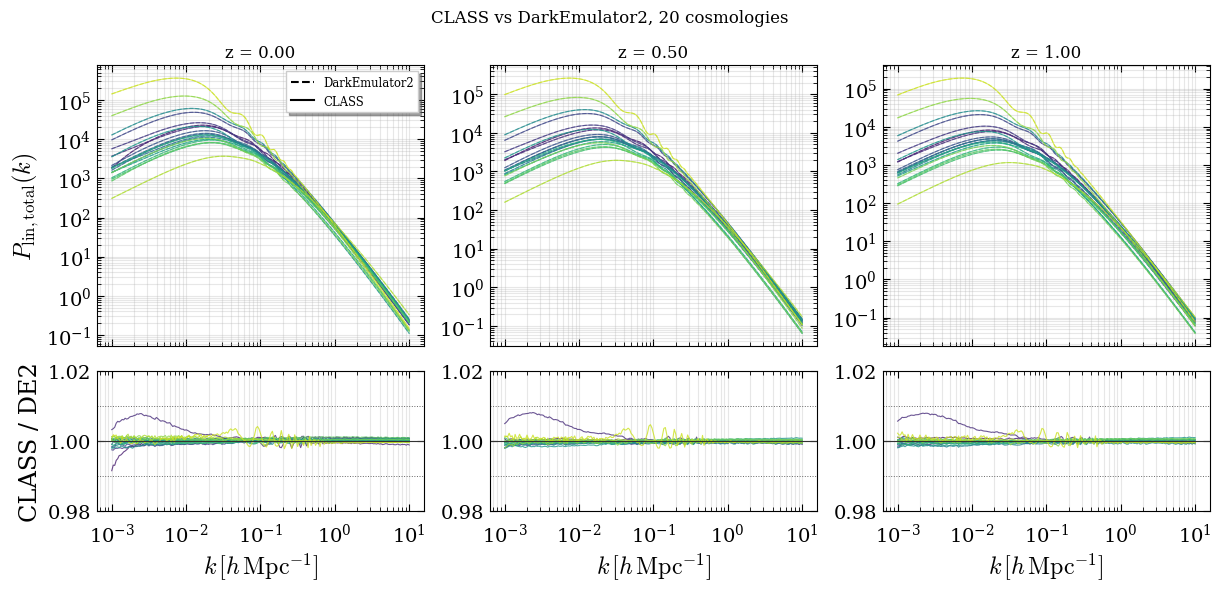

In [6]:
plot_comparison(class_result)

## EuclidEmulator2

In [7]:
import euclidemu2 as ee2


def to_ee2(p):
    return dict(As=p["As"], ns=p["ns"], Omb=p["omega_b"] / p["h0"]**2, Omm=p["Omega_m"], h=p["h0"], mnu=p["Mnu"], w0=p["w0"], wa=p["wa"])


def valid_ee2(p, emu):
    return 0.04 <= to_ee2(p)["Omb"] <= 0.06


ee2_params = sample_params_for("preset_ee2", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_ee2)
print(f"{len(ee2_params)} cosmologies selected for DE2 vs EuclidEmulator2.")

sample preset_ee2: 100%|██████████████████████████████████████████████████████| 20/20 [00:03<00:00,  5.07it/s, tries=98]

20 cosmologies selected for DE2 vs EuclidEmulator2.


In [8]:
def run_ee2(params, redshifts):
    emu = ee2.PyEuclidEmulator()
    pk = []
    for p in tqdm(params, desc="EuclidEmulator2"):
        k, _, plin, _ = emu.get_pnonlin(to_ee2(p), redshifts)
        pk.append(np.asarray(list(plin.values())))
    return k, np.asarray(pk)


t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(ee2_params)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_ee2, pk_ee2 = run_ee2(ee2_params, REDSHIFTS)
ee2_time = time.perf_counter() - t0

ee2_result = dict(label="EuclidEmulator2", params=ee2_params, k_de2=k_de2, pk_de2=pk_de2, k_tgt=k_ee2, pk_tgt=pk_ee2)
print(f"DE2:             {de2_time:.2f} sec")
print(f"EuclidEmulator2: {ee2_time:.2f} sec")

EuclidEmulator2: 100%|██████████████████████████████████████████████████████████████████| 20/20 [00:30<00:00,  1.53s/it]

DE2:             0.32 sec
EuclidEmulator2: 30.78 sec


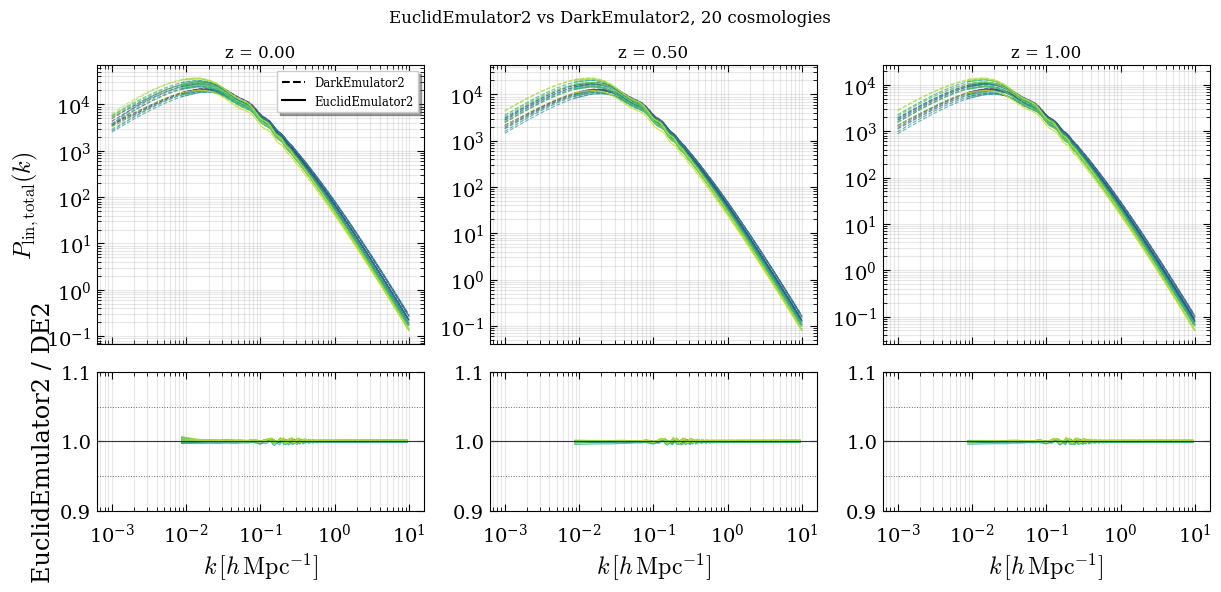

In [9]:
plot_comparison(ee2_result)

## BACCOemu

In [10]:
import baccoemu as bce

bacco_sigma8_emu = bce.Matter_powerspectrum(verbose=False)


def to_bacco(p):
    return dict(A_s=p["As"], ns=p["ns"], omega_baryon=p["omega_b"] / p["h0"]**2, omega_cold=p["Omega_m"] - p["Omega_nu"], hubble=p["h0"], neutrino_mass=p["Mnu"], w0=p["w0"], wa=p["wa"])


def valid_bacco(p, emu):
    b = to_bacco(p)
    if not (0.04 <= b["omega_baryon"] <= 0.06 and 0.23 <= b["omega_cold"] <= 0.40):
        return False
    return 0.73 <= bacco_sigma8_emu.get_sigma8(**b) <= 0.9


bacco_params = sample_params_for("preset_bacco", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_bacco)
print(f"{len(bacco_params)} cosmologies selected for DE2 vs BACCOemu.")

sample preset_bacco: 100%|███████████████████████████████████████████████████| 20/20 [00:07<00:00,  2.56it/s, tries=208]

20 cosmologies selected for DE2 vs BACCOemu.


In [11]:
def run_bacco(params, redshifts):
    emu = bce.Matter_powerspectrum(verbose=False)
    k = emu.emulator["nonlinear"]["k"]
    pk = []
    for p in tqdm(params, desc="BACCOemu"):
        b = to_bacco(p)
        pk.append([emu.get_linear_pk(k=k, cold=False, expfactor=1.0 / (1.0 + z), **b)[1] for z in redshifts])
    return k, np.asarray(pk)


t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(bacco_params)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_bacco, pk_bacco = run_bacco(bacco_params, REDSHIFTS)
bacco_time = time.perf_counter() - t0

bacco_result = dict(label="BACCOemu", params=bacco_params, k_de2=k_de2, pk_de2=pk_de2, k_tgt=k_bacco, pk_tgt=pk_bacco)
print(f"DE2:      {de2_time:.2f} sec")
print(f"BACCOemu: {bacco_time:.2f} sec")

BACCOemu: 100%|█████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 77.13it/s]

DE2:      0.26 sec
BACCOemu: 0.28 sec


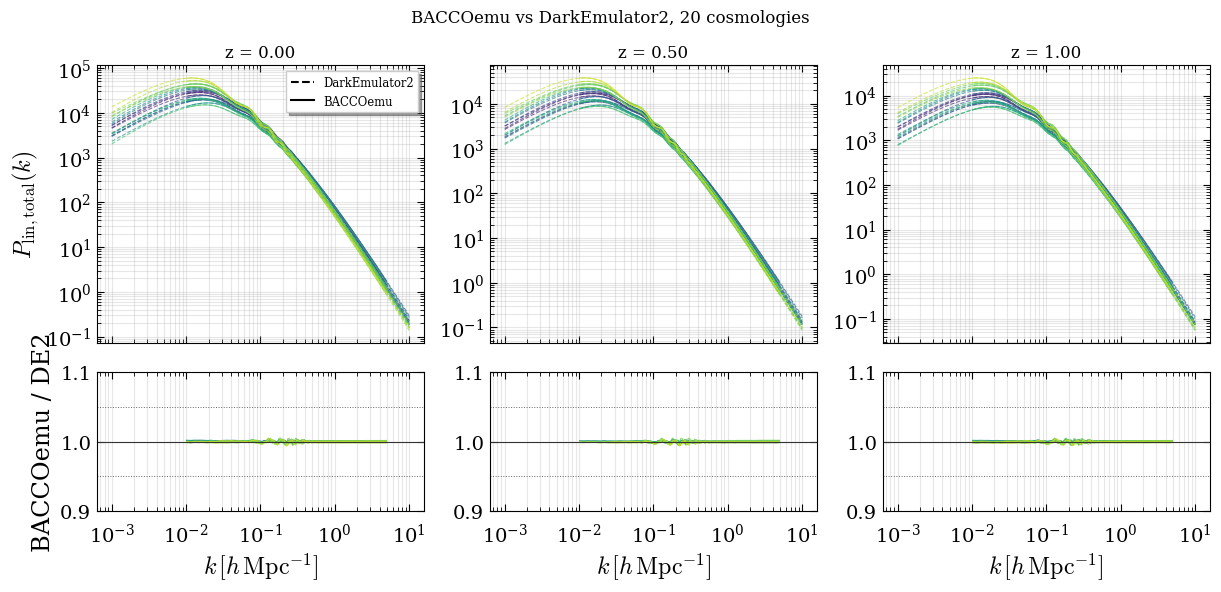

In [12]:
plot_comparison(bacco_result)

## GokuNEmu

In [13]:
from gokunemu import MatterPowerEmulator


def to_gokunemu(p):
    return dict(Omega_m=p["Omega_m"], Omega_b=p["omega_b"] / p["h0"]**2, h0=p["h0"], As=p["As"], ns=p["ns"], Mnu=p["Mnu"], w0=p["w0"], wa=p["wa"], Neff=3.044, alpha_s=0.0)


def valid_gokunemu(p, emu):
    return 0.040 <= to_gokunemu(p)["Omega_b"] <= 0.055


gokunemu_params = sample_params_for("preset_goku", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_gokunemu)
print(f"{len(gokunemu_params)} cosmologies selected for DE2 vs GokuNEmu.")

sample preset_goku: 100%|█████████████████████████████████████████████████████| 20/20 [00:01<00:00, 10.14it/s, tries=70]

20 cosmologies selected for DE2 vs GokuNEmu.


In [14]:
def run_gokunemu(params, redshifts):
    emu = MatterPowerEmulator()
    order = ["Omega_m", "Omega_b", "h0", "As", "ns", "w0", "wa", "Mnu", "Neff", "alpha_s"]
    cosmo = np.asarray([[to_gokunemu(p)[key] for key in order] for p in params])
    k, pk = emu.get_matter_power_lin(cosmo, redshifts=redshifts)
    return k, np.asarray(pk)


t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(gokunemu_params)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_gokunemu, pk_gokunemu = run_gokunemu(gokunemu_params, REDSHIFTS)
gokunemu_time = time.perf_counter() - t0

gokunemu_result = dict(label="GokuNEmu", params=gokunemu_params, k_de2=k_de2, pk_de2=pk_de2, k_tgt=k_gokunemu, pk_tgt=pk_gokunemu)
print(f"DE2:      {de2_time:.2f} sec")
print(f"GokuNEmu: {gokunemu_time:.2f} sec")

DE2 emulator: 100%|████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 247.08it/s]


DE2:      0.28 sec
GokuNEmu: 0.16 sec


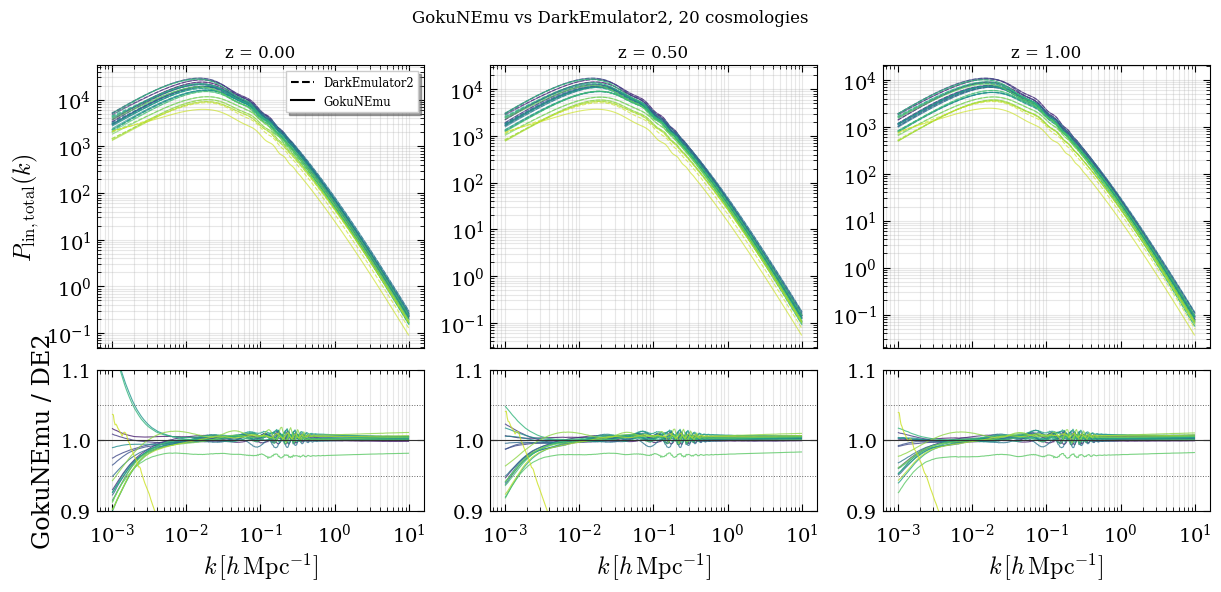

In [15]:
plot_comparison(gokunemu_result)

## CSSTemu

In [5]:
from CEmulator.Emulator import CBaseEmulator


# Use "single" to compare with the native CSSTemu training convention.
CSSTEMU_NEUTRINO_MASS_SPLIT = "degenerate"


def to_csstemu(p):
    Omegab = p["omega_b"] / p["h0"]**2
    Omeganu = p.get("Omega_nu", p["Mnu"] / (93.14 * p["h0"]**2))
    Omegac = p["Omega_m"] - Omeganu - Omegab
    return dict(Omegab=Omegab, Omegac=Omegac, H0=100.0 * p["h0"], As=p["As"], ns=p["ns"], w=p["w0"], wa=p["wa"], mnu=p["Mnu"])


def valid_csstemu(p, emu):
    c = to_csstemu(p)
    Omegacb = c["Omegab"] + c["Omegac"]
    return 0.04 <= c["Omegab"] <= 0.06 and 0.24 <= Omegacb <= 0.40 and c["Omegac"] > 0.0


csstemu_params = sample_params_for("preset_csstemu", flags=dict(nu=True, w0=True, wa=True, K=False), valid=valid_csstemu)
print(f"{len(csstemu_params)} cosmologies selected for DE2 vs CSSTemu.")

sample preset_csstemu: 100%|█████████████████████████████████████████████████| 20/20 [00:04<00:00,  4.08it/s, tries=156]

20 cosmologies selected for DE2 vs CSSTemu.


In [6]:
def run_csstemu(params, redshifts, klist):
    emu = CBaseEmulator(neutrino_mass_split=CSSTEMU_NEUTRINO_MASS_SPLIT)
    klist = np.asarray(klist)
    k = klist[(2.0 * np.pi / 1000.0 <= klist) & (klist <= 10.0)]
    pk = []
    for p in tqdm(params, desc="CSSTemu"):
        emu.set_cosmos(**to_csstemu(p))
        pk.append(emu.get_pklin(z=redshifts, k=k, Pcb=False, type="Emulator"))
    return k, np.asarray(pk)


t0 = time.perf_counter()
k_de2, pk_de2 = run_de2(csstemu_params)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_csstemu, pk_csstemu = run_csstemu(csstemu_params, REDSHIFTS, KLIST)
csstemu_time = time.perf_counter() - t0

csstemu_result = dict(
    label="CSSTemu",
    params=csstemu_params,
    k_de2=k_de2,
    pk_de2=pk_de2,
    k_tgt=k_csstemu,
    pk_tgt=pk_csstemu,
    ratio_ylim=(0.975, 1.025),
    ratio_lines=(0.99, 1.01),
)
print(f"DE2:     {de2_time:.2f} sec")
print(f"CSSTemu: {csstemu_time:.2f} sec")

CSSTemu: 100%|█████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 158.91it/s]

DE2:     0.26 sec
CSSTemu: 0.58 sec


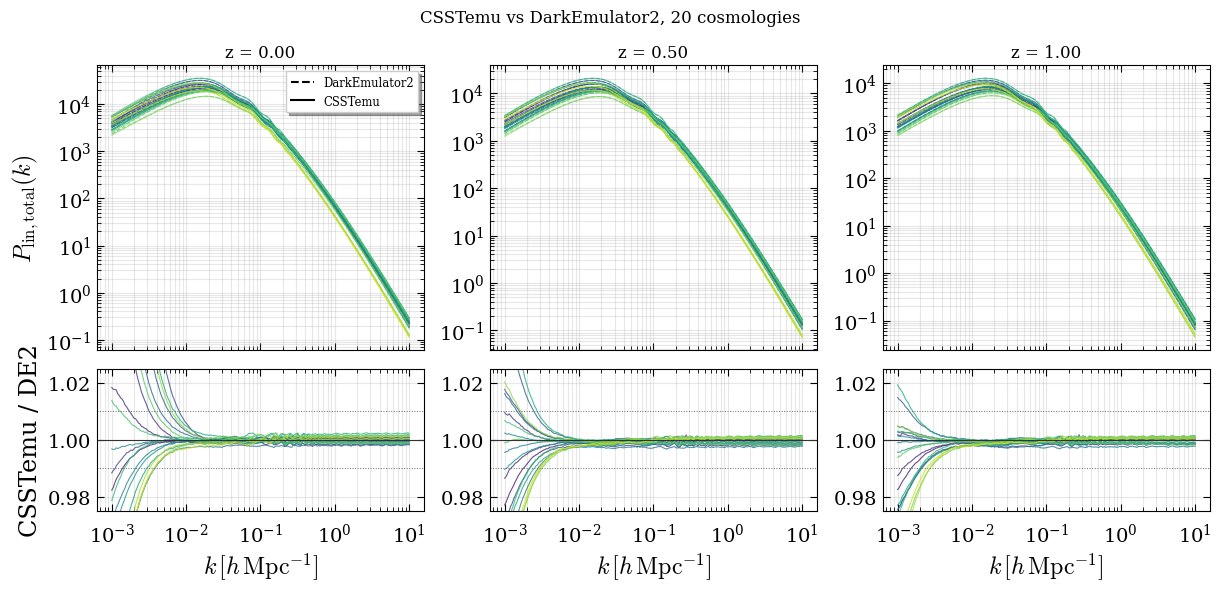

In [7]:
plot_comparison(csstemu_result)